# Value-Based Reinforcement Learning

In the previous notebook, we considered the prediction problem:

$$
\boxed{
\text{Given } \pi
\rightarrow
\text{estimate } V^\pi
}
$$

Monte Carlo and Temporal Difference learning allowed us to estimate value
functions from sampled experience without knowing the transition model.

However, reinforcement learning is usually interested in a more ambitious
problem:

> How can an agent improve its behavior and eventually learn a good or
> optimal policy from interaction?

This is the **control problem**.

For model-free control, action values are particularly useful:

$$
Q^\pi(x,u)=
\mathbb E_\pi
\left[
G_t
\mid
x_t=x,\;u_t=u
\right].
$$

If we know $Q(x,u)$, actions can be compared directly:

$$
u^*=
\arg\max_u Q(x,u).
$$

This notebook develops the progression:

$$
\boxed{
\text{TD Prediction}
\rightarrow
\text{Policy Improvement}
\rightarrow
\text{SARSA}
\rightarrow
\text{Q-learning}
}
$$

and then examines how value-based methods can be extended beyond tabular
state spaces using function approximation.

## Setup

This notebook uses the same small discrete environment as the previous
notebook so that we can focus on the transition from prediction to control.

The environment contains six states:

$$
\mathcal X=\{0,1,2,3,4,5\},
$$

with terminal states:

$$
0 \quad \text{and} \quad 5.
$$

The available actions are:

$$
\mathcal U=
\{\text{LEFT},\text{RIGHT}\}.
$$

Reaching the right terminal state produces reward:

$$
r=1,
$$

while all other transitions produce:

$$
r=0.
$$

In [11]:
import numpy as np
import matplotlib.pyplot as plt

In [12]:
N_STATES = 6

LEFT = 0
RIGHT = 1

TERMINAL_LEFT = 0
TERMINAL_RIGHT = 5

In [13]:
def environment_step(state, action):

    if action == LEFT:
        next_state = state - 1

    else:
        next_state = state + 1

    reward = (
        1.0
        if next_state == TERMINAL_RIGHT
        else 0.0
    )

    done = (
        next_state == TERMINAL_LEFT
        or next_state == TERMINAL_RIGHT
    )

    return next_state, reward, done

## 1. From Prediction to Control

In policy evaluation, the policy is fixed:

$$
\pi
\rightarrow
Q^\pi.
$$

The objective is only to estimate how good the current behavior is.

In control, the value estimate is also used to improve the policy.

Suppose:

$$
Q(x,\text{LEFT})=0.31
$$

and:

$$
Q(x,\text{RIGHT})=0.68.
$$

The action-value estimates suggest that RIGHT is currently the better action.

We can therefore improve the policy toward:

$$
\pi'(x)=
\arg\max_u Q(x,u).
$$

But changing the policy changes the experience generated by the agent.

That new experience changes the value estimates, which can again change the
policy.

Therefore, control creates a feedback loop:

$$
\boxed{
\text{Policy}
\rightarrow
\text{Experience}
\rightarrow
Q
\rightarrow
\text{Policy Improvement}
\rightarrow
\text{New Experience}
\rightarrow
\cdots
}
$$

This interaction between policy evaluation and policy improvement is called
**Generalized Policy Iteration.**

## 2. Exploration vs Exploitation

A greedy policy always selects the action with the highest current
action-value estimate:

$$
u=
\arg\max_{u'}Q(x,u').
$$

However, early in learning the estimates $Q(x,u)$ may be inaccurate because
many actions have not been sufficiently explored.

If the agent always chooses the currently best-looking action, it may never
discover better alternatives.

This creates the exploration-exploitation trade-off:

### Exploitation

Choose the action currently believed to be best:

$$
u=
\arg\max_{u'}Q(x,u').
$$

### Exploration

Try other actions to obtain information about their consequences.

A simple strategy that combines both is the $\epsilon$-greedy policy.

## 3. Epsilon-Greedy Action Selection

An $\epsilon$-greedy policy balances exploration and exploitation.

With probability:

$$
1-\epsilon,
$$

the agent chooses a greedy action:

$$
u=
\arg\max_{u'}Q(x,u').
$$

With probability:

$$
\epsilon,
$$

the agent chooses a random action.

Therefore:

$$
u=
\begin{cases}
\text{random action},
& \text{with probability }\epsilon,\\[2mm]
\arg\max_{u'}Q(x,u'),
& \text{with probability }1-\epsilon.
\end{cases}
$$

Early in training, exploration helps discover useful actions.

As the value estimates improve, the policy can increasingly exploit the
actions currently believed to be good.

In [14]:
def epsilon_greedy(Q, state, epsilon=0.1):

    # Exploration
    if np.random.rand() < epsilon:
        return np.random.choice(
            [LEFT, RIGHT]
        )

    # Exploitation
    q_values = Q[state]

    best_actions = np.flatnonzero(
        q_values == np.max(q_values)
    )

    # Random tie-breaking
    return np.random.choice(best_actions)

## 4. From TD Prediction to TD Control

The TD(0) update for state-value prediction was:

$$
V(x_t)
\leftarrow
V(x_t)+
\alpha
\left[
r_{t+1}+
\gamma V(x_{t+1})-
V(x_t)
\right].
$$

For control, we want to learn action values:

$$
Q(x_t,u_t).
$$

Suppose the agent observes:

$$
(x_t,u_t,r_{t+1},x_{t+1})
$$

and then selects the next action:

$$
u_{t+1}.
$$

The next state-action pair has estimated value:

$$
Q(x_{t+1},u_{t+1}).
$$

Therefore, a natural TD target is:

$$
y_t=
r_{t+1}
+
\gamma Q(x_{t+1},u_{t+1}).
$$

The TD error becomes:

$$
\delta_t=
r_{t+1}+
\gamma Q(x_{t+1},u_{t+1})-
Q(x_t,u_t).
$$

and the update is:

$$
Q(x_t,u_t)
\leftarrow
Q(x_t,u_t)
+
\alpha\delta_t.
$$

**This is the foundation of SARSA.**

## 5. SARSA

SARSA is named after the five quantities used in its update:

$$
\boxed{
S_t,\;
A_t,\;
R_{t+1},\;
S_{t+1},\;
A_{t+1}
}
$$

which gives:

$$
\boxed{\text{SARSA}}.
$$

The update is:

$$
Q(S_t,A_t)
\leftarrow
Q(S_t,A_t)+
\alpha
\left[
R_{t+1}+
\gamma Q(S_{t+1},A_{t+1})-
Q(S_t,A_t)
\right].
$$

The next action $A_{t+1}$ is selected using the same policy that is being
used to interact with the environment.

For example, if the behavior policy is $\epsilon$-greedy, then:

$$
A_{t+1}
\sim
\pi_\epsilon(\cdot|S_{t+1}).
$$

Therefore, SARSA learns the action values associated with the policy that is
actually generating the experience.

This makes SARSA an **on-policy** learning algorithm.

## 6. Implementing SARSA

We now apply SARSA to the same discrete environment used for TD prediction.

The action-value table has one entry for every state-action pair:

$$
Q(x,u).
$$

With six states and two actions:

$$
Q
\in
\mathbb R^{6\times2}.
$$

Initially:

$$
Q(x,u)=0.
$$

During every episode:

1. Select $u_t$ using the current $\epsilon$-greedy policy.
2. Execute $u_t$.
3. Observe $r_{t+1}$ and $x_{t+1}$.
4. Select $u_{t+1}$ using the current $\epsilon$-greedy policy.
5. Update $Q(x_t,u_t)$ using the SARSA target.
6. Continue from $(x_{t+1},u_{t+1})$.

Therefore, learning and policy improvement happen together.

In [15]:
gamma = 0.9
alpha = 0.1
epsilon = 0.1

n_episodes = 10_000

Q_sarsa = np.zeros(
    (N_STATES, 2)
)

In [16]:
for _ in range(n_episodes):

    state = np.random.choice(
        [1, 2, 3, 4]
    )

    action = epsilon_greedy(
        Q_sarsa,
        state,
        epsilon
    )

    done = False

    while not done:

        next_state, reward, done = environment_step(
            state,
            action
        )

        if done:

            td_target = reward

        else:

            next_action = epsilon_greedy(
                Q_sarsa,
                next_state,
                epsilon
            )

            td_target = (
                reward
                + gamma
                * Q_sarsa[next_state, next_action]
            )

        td_error = (
            td_target
            - Q_sarsa[state, action]
        )

        Q_sarsa[state, action] += (
            alpha * td_error
        )

        if not done:
            state = next_state
            action = next_action

## 7. Inspecting the Learned Action Values

After training, the table contains an estimate for each state-action pair:

$$
Q(x,\text{LEFT})
$$

and:

$$
Q(x,\text{RIGHT}).
$$

These values can now be used to construct a greedy policy:

$$
\pi(x)=
\arg\max_u Q(x,u).
$$

Unlike the value function $V(x)$, the action-value function directly tells us
which available action is currently preferred.

In [17]:
for state in range(1, 5):

    print(
        f"State {state}: "
        f"LEFT = {Q_sarsa[state, LEFT]:.3f}, "
        f"RIGHT = {Q_sarsa[state, RIGHT]:.3f}"
    )

State 1: LEFT = 0.000, RIGHT = 0.708
State 2: LEFT = 0.626, RIGHT = 0.797
State 3: LEFT = 0.702, RIGHT = 0.878
State 4: LEFT = 0.784, RIGHT = 1.000


In [18]:
action_names = {
    LEFT: "LEFT",
    RIGHT: "RIGHT"
}

for state in range(1, 5):

    best_action = np.argmax(
        Q_sarsa[state]
    )

    print(
        f"State {state}: "
        f"{action_names[best_action]}"
    )

State 1: RIGHT
State 2: RIGHT
State 3: RIGHT
State 4: RIGHT


## 8. On-Policy vs Off-Policy Learning

In reinforcement learning, it is useful to distinguish between two policies:

### Behavior policy

The policy used to generate experience:

$$
\mu(u|x).
$$

This determines which actions the agent actually executes in the environment.

### Target policy

The policy whose value function we want to learn:

$$
\pi(u|x).
$$

If both policies are the same:

$$
\mu=\pi,
$$

the algorithm is called **on-policy**.

If they are different:

$$
\mu\neq\pi,
$$

the algorithm is called **off-policy**.

## 9. Why SARSA Is On-Policy?

SARSA uses the update:

$$
Q(x_t,u_t)
\leftarrow
Q(x_t,u_t)+
\alpha
\left[
r_{t+1}+
\gamma Q(x_{t+1},u_{t+1})-
Q(x_t,u_t)
\right].
$$

The next action:

$$
u_{t+1}
$$

is selected using the current behavior policy.

If the behavior policy is $\epsilon$-greedy, then the SARSA target includes
the effect of exploration.

Therefore:

$$
\boxed{
\text{behavior policy}=
\text{target policy}
}
$$

and SARSA is an **on-policy** algorithm.

## 10. Q-Learning

Q-learning modifies the TD target used by SARSA.

SARSA uses:

$$
r_{t+1}
+
\gamma Q(x_{t+1},u_{t+1}).
$$

Q-learning instead uses the largest estimated action value at the next state:

$$
\boxed{
r_{t+1}
+
\gamma
\max_u Q(x_{t+1},u)
}
$$

The complete update is:

$$
\boxed{
Q(x_t,u_t)
\leftarrow
Q(x_t,u_t)+
\alpha
\left[
r_{t+1}+
\gamma
\max_uQ(x_{t+1},u)-
Q(x_t,u_t)
\right].
}
$$

The action used to generate experience may still come from an exploratory
policy such as $\epsilon$-greedy.

However, the TD target assumes that the best currently known action will be
selected at the next state.

## 11. Why Q-Learning Is Off-Policy?

Suppose the agent uses an $\epsilon$-greedy behavior policy to interact with
the environment.

The behavior policy may occasionally choose an exploratory action:

$$
u_{t+1}
\neq
\arg\max_uQ(x_{t+1},u).
$$

However, Q-learning does not use the value of the action actually selected.

Instead, it uses:

$$
\max_uQ(x_{t+1},u).
$$

Therefore, experience may be generated using one policy:

$$
\mu=
\epsilon\text{-greedy},
$$

while the value function is learned toward another policy:

$$
\pi=
\text{greedy}.
$$

Thus:

$$
\boxed{
\mu\neq\pi
}
$$

and Q-learning is an **off-policy** algorithm.

## 12. SARSA vs Q-Learning

SARSA and Q-learning differ only in how they construct the TD target.

### SARSA

$$
y_t^{SARSA}=
r_{t+1}
+
\gamma
Q(x_{t+1},u_{t+1})
$$

where:

$$
u_{t+1}
\sim
\pi(\cdot|x_{t+1}).
$$

SARSA evaluates and improves the policy that is actually being executed.

Therefore:

$$
\boxed{\text{SARSA = on-policy}}
$$

---

### Q-Learning

$$
y_t^{Q}=
r_{t+1}
+
\gamma
\max_uQ(x_{t+1},u).
$$

The behavior policy may explore, but the target assumes greedy action
selection.

Therefore:

$$
\boxed{\text{Q-learning = off-policy}}
$$

The two methods can therefore learn from the same type of transition:

$$
(x_t,u_t,r_{t+1},x_{t+1}),
$$

while interpreting the next decision differently.

## 13. Implementing Q-Learning

We now train a Q-learning agent in the same environment.

The behavior policy remains $\epsilon$-greedy so that the agent continues
exploring.

However, the TD target is constructed using:

$$
\max_uQ(x_{t+1},u).
$$

The interaction loop is:

1. Select $u_t$ using the $\epsilon$-greedy behavior policy.
2. Execute the action.
3. Observe $r_{t+1}$ and $x_{t+1}$.
4. Construct the greedy Q-learning target.
5. Update $Q(x_t,u_t)$.
6. Continue from $x_{t+1}$.

In [19]:
gamma = 0.9
alpha = 0.1
epsilon = 0.1

n_episodes = 10_000

Q_learning = np.zeros(
    (N_STATES, 2)
)

In [20]:
for _ in range(n_episodes):

    state = np.random.choice(
        [1, 2, 3, 4]
    )

    done = False

    while not done:

        # Behavior policy
        action = epsilon_greedy(
            Q_learning,
            state,
            epsilon
        )

        next_state, reward, done = environment_step(
            state,
            action
        )

        if done:

            td_target = reward

        else:

            td_target = (
                reward
                + gamma
                * np.max(Q_learning[next_state])
            )

        td_error = (
            td_target
            - Q_learning[state, action]
        )

        Q_learning[state, action] += (
            alpha * td_error
        )

        state = next_state

## 14. Inspecting the Q-Learning Policy

After training, the greedy policy can be extracted from the learned
action-value function:

$$
\pi(x)=
\arg\max_uQ(x,u).
$$

Since the reward is located at the right terminal state, we expect the
learned policy to prefer RIGHT from the non-terminal states.

In [21]:
for state in range(1, 5):

    left_value = Q_learning[
        state,
        LEFT
    ]

    right_value = Q_learning[
        state,
        RIGHT
    ]

    best_action = np.argmax(
        Q_learning[state]
    )

    print(
        f"State {state}: "
        f"LEFT={left_value:.3f}, "
        f"RIGHT={right_value:.3f}, "
        f"Policy={action_names[best_action]}"
    )

State 1: LEFT=0.000, RIGHT=0.729, Policy=RIGHT
State 2: LEFT=0.656, RIGHT=0.810, Policy=RIGHT
State 3: LEFT=0.729, RIGHT=0.900, Policy=RIGHT
State 4: LEFT=0.810, RIGHT=1.000, Policy=RIGHT


## 15. Comparing SARSA and Q-Learning

SARSA and Q-learning often learn similar behavior in simple environments.

However, their targets represent different policies.

SARSA uses:

$$
Q(x_{t+1},u_{t+1}),
$$

so exploratory actions influence the learned value function.

Q-learning uses:

$$
\max_uQ(x_{t+1},u),
$$

so it learns toward greedy behavior even while exploratory actions are used
to gather experience.

Therefore, the important difference is not necessarily visible in the final
policy of a simple environment.

The difference lies in:

$$
\boxed{
\text{which policy the value estimates correspond to}
}
$$

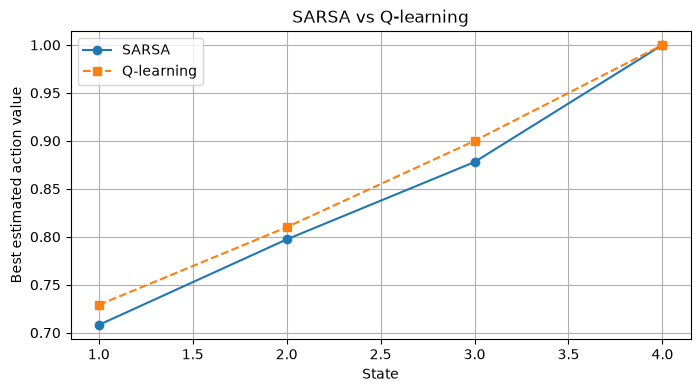

In [22]:
states = np.arange(1, 5)

sarsa_best_values = np.max(
    Q_sarsa[states],
    axis=1
)

q_learning_best_values = np.max(
    Q_learning[states],
    axis=1
)

plt.figure(figsize=(8, 4))

plt.plot(
    states,
    sarsa_best_values,
    marker="o",
    label="SARSA"
)

plt.plot(
    states,
    q_learning_best_values,
    marker="s",
    linestyle="--",
    label="Q-learning"
)

plt.xlabel("State")
plt.ylabel("Best estimated action value")
plt.title("SARSA vs Q-learning")
plt.legend()
plt.grid()

plt.show()

## 16. The Generalized Policy Iteration View

SARSA and Q-learning can both be understood through Generalized Policy
Iteration.

Two processes occur simultaneously:

### Value estimation

Experience is used to improve estimates of:

$$
Q(x,u).
$$

### Policy improvement

The current action values are used to make the policy increasingly greedy:

$$
\pi(x)
\rightarrow
\arg\max_uQ(x,u).
$$

These two processes interact:

$$
\boxed{
Q
\rightarrow
\pi
\rightarrow
\text{experience}
\rightarrow
Q
\rightarrow
\pi
\rightarrow
\cdots
}
$$

**NOTE:** Unlike classical Policy Iteration, evaluation does not need to converge
completely before policy improvement occurs.

Learning and improvement can happen continuously during interaction.

This is the central idea of Generalized Policy Iteration.

## 17. Why Tabular Q-Learning Does Not Scale

In tabular Q-learning, we store one value for every state-action pair:

$$
Q(x,u).
$$

This works when the state and action spaces are small and discrete.

For example, with:

$$
|\mathcal X|=100
$$

and:

$$
|\mathcal U|=4,
$$

we only need:

$$
100\times4=400
$$

Q-values.

However, many robotics and autonomous-driving problems have large or
continuous state spaces.

For example, a vehicle state may contain:

$$
x=
[p_x,p_y,\psi,v,\ldots].
$$

These variables are continuous, so the number of possible states is
effectively infinite.

A table such as:

$$
Q[x,u]
$$

is therefore no longer practical.

This motivates replacing the table with a parameterized function:

$$
\boxed{
Q(x,u)
\approx
Q_\theta(x,u)
}
$$

where $\theta$ represents learnable parameters.

## 18. Approximating the Q-Function

Instead of storing a separate value for every state-action pair, we can
represent the action-value function using a parameterized model:

$$
Q_\theta(x,u).
$$

For discrete actions, a neural network can take the state as input and return
one Q-value for every possible action:

$$
x
\rightarrow
Q_\theta(x,\cdot).
$$

For example, with two actions:

$$
Q_\theta(x,\cdot)=
\begin{bmatrix}
Q_\theta(x,\text{LEFT}) \\
Q_\theta(x,\text{RIGHT})
\end{bmatrix}.
$$

Action selection remains greedy:

$$
u^*=
\arg\max_u Q_\theta(x,u).
$$

The difference is that the Q-function is now represented by shared parameters
rather than an explicit table.

## 19. From the Q-Learning Update to a Learning Objective

Tabular Q-learning uses the update:

$$
Q(x_t,u_t)
\leftarrow
Q(x_t,u_t)
+
\alpha
\left[
y_t-Q(x_t,u_t)
\right],
$$

where the target is:

$$
y_t=
r_{t+1}
+
\gamma
\max_u Q(x_{t+1},u).
$$

When $Q$ is represented by a neural network, we cannot directly modify one
table entry.

Instead, we train the network to make:

$$
Q_\theta(x_t,u_t)
$$

close to the Q-learning target:

$$
y_t.
$$

A simple squared-error objective is:

$$
\boxed{
L(\theta)=
\frac{1}{2}
\left[
y_t-
Q_\theta(x_t,u_t)
\right]^2.
}
$$

The network parameters are then updated using gradient descent:

$$
\theta
\leftarrow
\theta-
\eta
\nabla_\theta L(\theta).
$$

## 20. A Minimal Neural Q-Function

To understand function approximation, we first replace the Q-table with a
small neural network.

The network receives the state:

$$
x
$$

and outputs one Q-value for each discrete action:

$$
Q_\theta(x,\cdot)=
[
Q_\theta(x,\text{LEFT}),
Q_\theta(x,\text{RIGHT})
].
$$

Although our current environment is small enough for a Q-table, this allows us
to study the transition from tabular Q-learning to deep Q-learning.

In [23]:
import torch
import torch.nn as nn
import torch.optim as optim

In [24]:
class QNetwork(nn.Module):

    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(1, 32),
            nn.ReLU(),
            nn.Linear(32, 32),
            nn.ReLU(),
            nn.Linear(32, 2)
        )

    def forward(self, state):
        return self.network(state)

In [25]:
q_network = QNetwork()

optimizer = optim.Adam(
    q_network.parameters(),
    lr=1e-3
)

## 21. State Representation

A neural network expects numerical feature vectors as input.

In the current environment, the state is an integer:

$$
x\in\{1,2,3,4\}.
$$

We normalize the state to approximately:

$$
[0,1]
$$

using:

$$
\tilde x=
\frac{x}{N_{\text{states}}-1}.
$$

In larger problems, this role is played by a richer observation vector such
as vehicle position, velocity, heading, sensor features, or learned latent
representations.

In [26]:
def state_to_tensor(state):

    normalized_state = (
        state / (N_STATES - 1)
    )

    return torch.tensor(
        [[normalized_state]],
        dtype=torch.float32
    )

## 22. Neural Q-Learning Update

For a transition:

$$
(x_t,u_t,r_{t+1},x_{t+1}),
$$

the Q-learning target is:

$$
y_t=
r_{t+1}
+
\gamma
\max_uQ_\theta(x_{t+1},u).
$$

For terminal transitions:

$$
y_t=r_{t+1}.
$$

The predicted value is:

$$
Q_\theta(x_t,u_t).
$$

The loss is:

$$
L(\theta)=
\left[
y_t-Q_\theta(x_t,u_t)
\right]^2.
$$

Gradient descent then changes the network parameters so that the predicted
Q-value moves toward the TD target.

In [27]:
def neural_q_update(
    q_network,
    optimizer,
    state,
    action,
    reward,
    next_state,
    done,
    gamma=0.9
):

    state_tensor = state_to_tensor(state)

    q_values = q_network(state_tensor)

    q_value = q_values[0, action]

    with torch.no_grad():

        if done:
            target = torch.tensor(
                reward,
                dtype=torch.float32
            )

        else:

            next_state_tensor = state_to_tensor(
                next_state
            )

            next_q_values = q_network(
                next_state_tensor
            )

            target = (
                reward
                + gamma
                * torch.max(next_q_values)
            )

    loss = (
        target - q_value
    ) ** 2

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    return loss.item()

## 23. Epsilon-Greedy Action Selection With a Neural Q-Function

The exploration strategy does not fundamentally change when replacing a
Q-table with a neural network.

With probability:

$$
\epsilon,
$$

we select a random action.

Otherwise, we evaluate:

$$
Q_\theta(x,\cdot)
$$

and select:

$$
u=
\arg\max_uQ_\theta(x,u).
$$

In [28]:
def neural_epsilon_greedy(
    q_network,
    state,
    epsilon
):

    if np.random.rand() < epsilon:

        return np.random.choice(
            [LEFT, RIGHT]
        )

    with torch.no_grad():

        state_tensor = state_to_tensor(
            state
        )

        q_values = q_network(
            state_tensor
        )[0]

        best_value = torch.max(q_values)

        best_actions = torch.where(
            q_values == best_value
        )[0]

        action = best_actions[
            torch.randint(
                len(best_actions),
                (1,)
            )
        ]

    return int(action.item())

## 24. Training With Online Neural Q-Learning

We can now replace the tabular Q-learning update with a neural-network update.

The interaction loop remains:

$$
x_t
\rightarrow
u_t
\rightarrow
r_{t+1},x_{t+1}
\rightarrow
\text{Q-learning target}
\rightarrow
\text{network update}.
$$

The main difference is that updating one state-action pair now modifies shared
network parameters.

Therefore, an update from one state may also change Q-value predictions at
other states.

This generalization is the main reason function approximation can scale beyond
tabular state spaces.

In [29]:
q_network = QNetwork()

optimizer = optim.Adam(
    q_network.parameters(),
    lr=1e-3
)

gamma = 0.9
epsilon = 0.1

n_episodes = 5000

loss_history = []

In [30]:
for _ in range(n_episodes):

    state = np.random.choice(
        [1, 2, 3, 4]
    )

    done = False

    while not done:

        action = neural_epsilon_greedy(
            q_network,
            state,
            epsilon
        )

        next_state, reward, done = environment_step(
            state,
            action
        )

        loss = neural_q_update(
            q_network,
            optimizer,
            state,
            action,
            reward,
            next_state,
            done,
            gamma
        )

        loss_history.append(loss)

        state = next_state

## 25. Inspecting the Learned Neural Q-Function

After training, we can evaluate the network at each state.

The network should produce:

$$
Q_\theta(x,\text{LEFT})
$$

and:

$$
Q_\theta(x,\text{RIGHT}).
$$

The corresponding greedy policy is:

$$
\pi(x)=
\arg\max_uQ_\theta(x,u).
$$

In [31]:
for state in range(1, 5):

    with torch.no_grad():

        q_values = q_network(
            state_to_tensor(state)
        )[0]

    left_value = q_values[LEFT].item()
    right_value = q_values[RIGHT].item()

    best_action = torch.argmax(
        q_values
    ).item()

    print(
        f"State {state}: "
        f"LEFT={left_value:.3f}, "
        f"RIGHT={right_value:.3f}, "
        f"Policy={action_names[best_action]}"
    )

State 1: LEFT=0.091, RIGHT=0.729, Policy=RIGHT
State 2: LEFT=0.647, RIGHT=0.810, Policy=RIGHT
State 3: LEFT=0.726, RIGHT=0.903, Policy=RIGHT
State 4: LEFT=0.799, RIGHT=0.993, Policy=RIGHT


## 26. Why Neural Q-Learning Is Not Yet DQN?

Replacing a Q-table with a neural network introduces several difficulties.

The network is trained on transitions generated sequentially by the current
policy.

This creates two important problems.

### Correlated data

Consecutive transitions:

$$
(x_t,u_t,r_{t+1},x_{t+1}),
$$

$$
(x_{t+1},u_{t+1},r_{t+2},x_{t+2})
$$

are strongly correlated.

Neural-network optimization generally works better when training samples are
less correlated.

### Moving targets

The Q-learning target contains the same function that is currently being
trained:

$$
y_t=
r_{t+1}
+
\gamma
\max_uQ_\theta(x_{t+1},u).
$$

As $\theta$ changes, the target itself changes.

Therefore, the network is simultaneously:

- changing its prediction,
- changing the target it is trying to match.

This can make learning unstable.

Deep Q-Networks introduce mechanisms specifically designed to address these
problems.

## 27. Experience Replay

In online neural Q-learning, consecutive transitions are strongly correlated:

$$
(x_t,u_t,r_{t+1},x_{t+1}),
$$

$$
(x_{t+1},u_{t+1},r_{t+2},x_{t+2}),
$$

and so on.

Training a neural network directly on this sequence can make optimization
unstable.

Instead, we store transitions in a **replay buffer**:

$$
\mathcal D=
\{
(x,u,r,x',d)
\},
$$

where $d$ indicates whether the transition terminated the episode.

During learning, we randomly sample a mini-batch:

$$
B \sim \mathcal D.
$$

The network is then updated using this randomly sampled experience rather
than only the most recent transition.

Experience replay therefore:

1. reduces temporal correlation between training samples,
2. allows old experience to be reused,
3. improves data efficiency,
4. separates data collection from individual gradient updates.

In [32]:
from collections import deque
import random

In [33]:
class ReplayBuffer:

    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def add(
        self,
        state,
        action,
        reward,
        next_state,
        done
    ):
        self.buffer.append(
            (
                state,
                action,
                reward,
                next_state,
                done
            )
        )

    def sample(self, batch_size):
        return random.sample(
            self.buffer,
            batch_size
        )

    def __len__(self):
        return len(self.buffer)

In [34]:
replay_buffer = ReplayBuffer(
    capacity=10_000
)

## 29. Learning From Mini-Batches

Instead of performing an update from one transition, DQN samples a mini-batch
of transitions from the replay buffer:

$$
\{
(x_i,u_i,r_i,x'_i,d_i)
\}_{i=1}^{B}.
$$

For every transition, we construct a TD target:

$$
y_i=
r_i
+
\gamma(1-d_i)
\max_uQ(x'_i,u).
$$

The factor:

$$
1-d_i
$$

removes the future-value term when the transition is terminal.

The Q-network predicts:

$$
Q_\theta(x_i,u_i).
$$

The mini-batch loss is then:

$$
\boxed{
L(\theta)=
\frac{1}{B}
\sum_{i=1}^{B}
\left[
y_i-Q_\theta(x_i,u_i)
\right]^2.
}
$$

A single gradient step therefore learns from several transitions collected
at different times.

## 30. The Moving-Target Problem

Experience replay improves the distribution of training data, but another
problem remains.

The Q-learning target is:

$$
y=
r
+
\gamma
\max_uQ_\theta(x',u).
$$

At the same time, the prediction being optimized is:

$$
Q_\theta(x,u).
$$

Therefore, the same network parameters $\theta$ determine both:

- the prediction,
- the target.

After a gradient update:

$$
\theta_k
\rightarrow
\theta_{k+1},
$$

the prediction changes, but the target also changes.

The network is therefore attempting to fit a target that continuously moves
as the network itself is updated.

This feedback can make neural Q-learning unstable.

## 31. Target Network

DQN introduces a second Q-network to stabilize the TD target.

### Online network

$$
Q_\theta(x,u)
$$

This network is updated by gradient descent.

### Target network

$$
Q_{\theta^-}(x,u)
$$

This network is used to construct the TD target.

The DQN target becomes:

$$
\boxed{
y=
r
+
\gamma(1-d)
\max_uQ_{\theta^-}(x',u).
}
$$

The prediction is still:

$$
Q_\theta(x,u).
$$

Therefore, the loss becomes:

$$
\boxed{
L(\theta)=
\frac{1}{B}
\sum_i
\left[
r_i+
\gamma(1-d_i)
\max_uQ_{\theta^-}(x'_i,u)-
Q_\theta(x_i,u_i)
\right]^2.
}
$$

Only the online network parameters $\theta$ are updated by gradient descent.

The target network parameters $\theta^-$ remain fixed temporarily.

## 32. Updating the Target Network

The target network is not directly optimized using gradient descent.

Instead, its parameters are periodically copied from the online network:

$$
\boxed{
\theta^-
\leftarrow
\theta.
}
$$

For several gradient updates, the target network remains fixed:

$$
Q_{\theta^-}.
$$

Meanwhile, the online network continues learning:

$$
\theta
\rightarrow
\theta'
\rightarrow
\theta''
\rightarrow
\cdots
$$

After a chosen number of updates, the target network is synchronized again:

$$
\theta^-
\leftarrow
\theta.
$$

This makes the TD target change more slowly than the online Q-function,
improving training stability.

## 33. Online and Target Q-Networks

DQN maintains two networks with the same architecture:

$$
Q_\theta
\qquad\text{and}\qquad
Q_{\theta^-}.
$$

Initially, both networks contain identical parameters.

The online network is trained continuously.

The target network is updated periodically by copying parameters from the
online network.

In [35]:
online_network = QNetwork()
target_network = QNetwork()

In [36]:
target_network.load_state_dict(
    online_network.state_dict()
)

<All keys matched successfully>

In [37]:
optimizer = optim.Adam(
    online_network.parameters(),
    lr=1e-3
)

## 34. DQN Mini-Batch Update

A DQN training update proceeds as follows:

1. Sample a random mini-batch from the replay buffer.
2. Evaluate the selected actions using the online network.
3. Evaluate the next states using the target network.
4. Construct the TD targets.
5. Compute the mean squared TD error.
6. Update only the online network.

For each sampled transition:

$$
(x_i,u_i,r_i,x'_i,d_i),
$$

the target is:

$$
y_i=
r_i
+
\gamma(1-d_i)
\max_u
Q_{\theta^-}(x'_i,u).
$$

The prediction is:

$$
Q_\theta(x_i,u_i).
$$

In [39]:
def dqn_update(
    online_network,
    target_network,
    optimizer,
    replay_buffer,
    batch_size,
    gamma=0.9
):

    batch = replay_buffer.sample(
        batch_size
    )

    states, actions, rewards, next_states, dones = zip(
        *batch
    )

    states = torch.tensor(
        states,
        dtype=torch.float32
    ).unsqueeze(1) / (N_STATES - 1)

    next_states = torch.tensor(
        next_states,
        dtype=torch.float32
    ).unsqueeze(1) / (N_STATES - 1)

    actions = torch.tensor(
        actions,
        dtype=torch.long
    )

    rewards = torch.tensor(
        rewards,
        dtype=torch.float32
    )

    dones = torch.tensor(
        dones,
        dtype=torch.float32
    )

    q_values = online_network(
        states
    )

    selected_q_values = q_values.gather(
        1,
        actions.unsqueeze(1)
    ).squeeze(1)

    with torch.no_grad():

        next_q_values = target_network(
            next_states
        )

        max_next_q_values = torch.max(
            next_q_values,
            dim=1
        ).values

        targets = (
            rewards
            + gamma
            * (1 - dones)
            * max_next_q_values
        )

    loss = torch.mean(
        (targets - selected_q_values) ** 2
    )

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    return loss.item()

## 35. DQN Architecture

DQN combines Q-learning with neural function approximation and two important
stabilization mechanisms.

### Interaction

The behavior policy selects actions using the online Q-network:

$$
u_t
\sim
\epsilon\text{-greedy}
\left(
Q_\theta(x_t,\cdot)
\right).
$$

The environment returns:

$$
r_{t+1},x_{t+1}.
$$

The transition is stored:

$$
(x_t,u_t,r_{t+1},x_{t+1},d_t)
\rightarrow
\mathcal D.
$$

### Learning

A random mini-batch is sampled:

$$
B\sim\mathcal D.
$$

The online network predicts:

$$
Q_\theta(x_i,u_i).
$$

The target network constructs:

$$
y_i=
r_i
+
\gamma(1-d_i)
\max_uQ_{\theta^-}(x'_i,u).
$$

The online network minimizes:

$$
L(\theta)=
\frac{1}{B}
\sum_i
\left[
y_i-Q_\theta(x_i,u_i)
\right]^2.
$$

Periodically:

$$
\theta^-\leftarrow\theta.
$$

## 36. Complete DQN Training Loop

We now combine all components of Deep Q-Learning into a single training
algorithm.

The interaction loop contains two separate processes:

### Environment Interaction

The online network selects actions using an $\epsilon$-greedy behavior policy.

Every interaction generates a transition:

$$
(x_t,u_t,r_{t+1},x_{t+1},d_t),
$$

which is stored inside the replay buffer.

### Learning

After sufficient experience has been collected:

1. Sample a random mini-batch from the replay buffer.
2. Compute predictions using the online network.
3. Compute TD targets using the target network.
4. Perform one gradient update.
5. Periodically synchronize the target network.

Unlike tabular Q-learning, data collection and learning are partially
decoupled through the replay buffer.

### DQN Training Algorithm

```text
Initialize:
    Online Q-network Qθ
    Target Q-network Qθ⁻ ← Qθ
    Replay buffer D

for each episode:

    Reset environment
    Observe initial state s

    while episode not finished:

        Choose action using ε-greedy(Qθ)

        Execute action

        Observe (r, s', done)

        Store transition in replay buffer D

        if replay buffer contains enough samples:

            Sample random mini-batch B

            Compute targets using Qθ⁻

            Compute loss:
                L = (target - Qθ)^2

            Gradient descent on Qθ

        Every C gradient steps:

            Copy Qθ → Qθ⁻

        s ← s'
```

## 37. DQN Training Loop Implementation

The training loop now contains three frequencies:

- Environment frequency (collect transitions).
- Gradient frequency (sample replay buffer and update the online network).
- Target synchronization frequency (copy parameters periodically).

These frequencies do not need to be identical.

In [40]:
BATCH_SIZE = 32
TARGET_UPDATE_FREQ = 200      # gradient updates
MIN_BUFFER_SIZE = 200
EPSILON_START = 1.0
EPSILON_END = 0.05
EPSILON_DECAY = 0.995

In [41]:
online_network = QNetwork()
target_network = QNetwork()

target_network.load_state_dict(
    online_network.state_dict()
)

optimizer = optim.Adam(
    online_network.parameters(),
    lr=1e-3
)

replay_buffer = ReplayBuffer(
    capacity=5000
)

epsilon = EPSILON_START

In [42]:
loss_history = []
episode_reward_history = []

gradient_steps = 0

for episode in range(300):

    state = np.random.choice([1,2,3,4])
    done = False
    episode_reward = 0

    while not done:

        action = neural_epsilon_greedy(
            online_network,
            state,
            epsilon
        )

        next_state, reward, done = environment_step(
            state,
            action
        )

        replay_buffer.add(
            state,
            action,
            reward,
            next_state,
            done
        )

        episode_reward += reward

        if len(replay_buffer) >= MIN_BUFFER_SIZE:

            loss = dqn_update(
                online_network,
                target_network,
                optimizer,
                replay_buffer,
                BATCH_SIZE,
                gamma=0.9
            )

            loss_history.append(loss)

            gradient_steps += 1

            if gradient_steps % TARGET_UPDATE_FREQ == 0:

                target_network.load_state_dict(
                    online_network.state_dict()
                )

        state = next_state

    episode_reward_history.append(
        episode_reward
    )

    epsilon = max(
        EPSILON_END,
        epsilon * EPSILON_DECAY
    )

## 38. Visualizing Training

We monitor two quantities during training:

1. Episode reward.
2. TD loss.

The reward measures policy performance.

The TD loss measures how well the online network matches the current TD
targets.

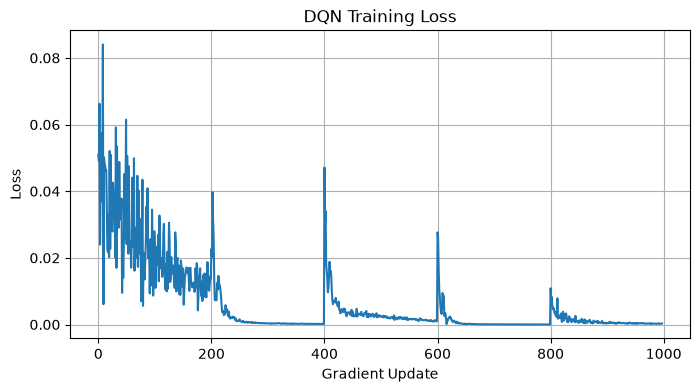

In [43]:
plt.figure(figsize=(8,4))
plt.plot(loss_history)
plt.title("DQN Training Loss")
plt.xlabel("Gradient Update")
plt.ylabel("Loss")
plt.grid()
plt.show()

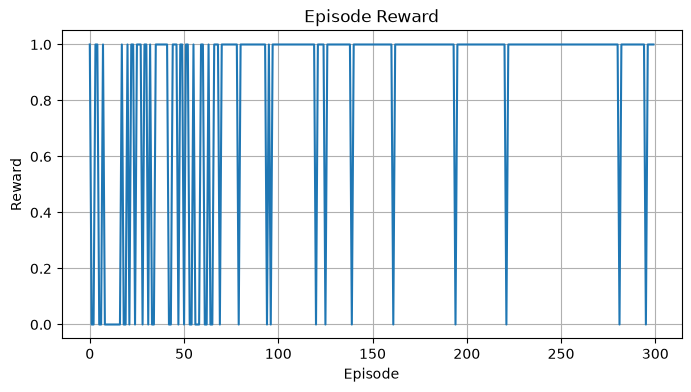

In [44]:
plt.figure(figsize=(8,4))
plt.plot(episode_reward_history)
plt.title("Episode Reward")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.grid()
plt.show()

## 39. Evaluating the Learned DQN Policy

During evaluation we no longer need exploration.

We use the greedy policy:

$$
u=
\arg\max_uQ_\theta(x,u).
$$

This is the deployment policy learned by DQN.

In [45]:
def greedy_policy(network, state):

    with torch.no_grad():

        q = network(
            state_to_tensor(state)
        )[0]

    return torch.argmax(q).item()

In [46]:
for state in range(1,5):

    action = greedy_policy(
        online_network,
        state
    )

    print(
        f"State {state}: "
        f"{action_names[action]}"
    )

State 1: RIGHT
State 2: RIGHT
State 3: RIGHT
State 4: RIGHT


## 40. Why DQN Works Well for Discrete Actions?

DQN assumes that the network outputs one value for every possible action.

For discrete actions:

$$
Q_\theta(x,\cdot)=
[Q(x,a_1),Q(x,a_2),...,Q(x,a_m)].
$$

The greedy action is simply:

$$
\arg\max_aQ(x,a).
$$

Examples include:

- LEFT / RIGHT
- UP / DOWN
- Atari joystick actions
- Discrete navigation commands

The computational cost grows linearly with the number of discrete actions.

## 41. Why DQN Struggles With Continuous Actions?

Suppose a vehicle's control is:

$$
u=
[\delta,a]
$$

where:

- steering angle $\delta$ is continuous,
- acceleration $a$ is continuous.

Now the action space becomes:

$$
u\in\mathbb R^2.
$$

The Q-learning target requires:

$$
\boxed{
\max_uQ(x,u).
}
$$

For discrete actions this is easy because every action is evaluated.

For continuous actions, infinitely many actions exist.

The maximization itself becomes another optimization problem.

This makes vanilla DQN impractical for continuous control.

## 42. Connecting DQN to Optimal Control and Robotics

This project has now reached an important connection.

### MPC / iLQR

We previously solved:

$$
u^*=
\arg\min_uJ(x,u)
$$

by performing optimization online using a dynamics model.

Characteristics:

- known dynamics,
- optimization performed at every control cycle,
- continuous control inputs,
- model-based.

### DQN

DQN instead learns:

$$
Q_\theta(x,u).
$$

Action selection becomes:

$$
u^*=
\arg\max_uQ_\theta(x,u).
$$

Characteristics:

- no explicit dynamics model,
- policy obtained from learned value estimates,
- works naturally for discrete actions,
- model-free.

### The Fundamental Difference

MPC computes the optimal action online through optimization.

DQN computes the optimal action through a learned value function.

This is the transition from **planning with a model** to **learning from
experience**.

## 43. Limitations of Value-Based Methods

Value-based reinforcement learning has several important limitations.

### 1. Continuous actions

The maximization:

$$
\max_uQ(x,u)
$$

is difficult in continuous action spaces.

### 2. Large action spaces

The network output size increases with the number of actions.

### 3. Exploration remains difficult

Choosing effective exploratory actions becomes increasingly challenging in
high-dimensional environments.

### 4. Sparse rewards

When rewards are delayed or infrequent, learning can become very sample
inefficient.

These limitations motivate learning the policy directly instead of maximizing
a value function over actions.

## 44. Why Learn the Policy Directly?

Value-based methods learn:

$$
Q_\theta(x,u)
$$

and derive the policy using:

$$
\pi(x)=
\arg\max_uQ_\theta(x,u).
$$

For continuous actions, computing:

$$
\arg\max_uQ_\theta(x,u)
$$

can itself become difficult.

Policy-gradient methods take a different approach.

Instead of learning action values first, they directly learn a parameterized
policy:

$$
\boxed{
\pi_\theta(u|x).
}
$$

The neural network outputs actions (or action distributions) directly.

This removes the explicit maximization over the action space and naturally
supports continuous control.

This is the foundation for Actor-Critic methods, DDPG, TD3, SAC, PPO, and
many modern robotics algorithms.

## 45. Notebook 13 Summary — Value-Based Reinforcement Learning

This notebook extended Temporal Difference learning from prediction to control.

### Prediction

- Monte Carlo estimates values from complete returns.
- TD estimates values using bootstrapping.

### Control

- Introduced the action-value function:

$$
Q^\pi(x,u).
$$

- Improved policies using $\epsilon$-greedy exploration.

### SARSA

- On-policy TD control.
- Learns the value of the behavior policy.

### Q-learning

- Off-policy TD control.
- Learns toward the greedy target policy.

### Function Approximation

- Replaced Q-tables with neural networks:

$$
Q_\theta(x,u).
$$

### Deep Q-Network (DQN)

Added two mechanisms for stable deep reinforcement learning:

- Experience Replay.
- Target Network.

### Key Insight

The progression through reinforcement learning is now:

$$
\boxed{
\text{Prediction}
\rightarrow
\text{Control}
\rightarrow
\text{Function Approximation}
\rightarrow
\text{Deep Q-Learning}
}
$$

The next notebook begins a new family of algorithms:

$$
\boxed{
\text{Policy Gradients}
\rightarrow
\text{Actor-Critic}
\rightarrow
\text{PPO}
}
$$

where the policy itself becomes the learnable function.